# Function Approximation with the `MultiDense` Custom Keras Layer

This notebook demonstrates the use of a custom Keras layer — **`MultiDense`** — for **1-D function approximation via supervised regression**.

We will:
1. Define and register the `MultiDense` layer.
2. Generate a synthetic dataset from a known mathematical function.
3. Build two models: a **baseline MLP** and a **MultiDense model**.
4. Train both models with full reproducibility guarantees.
5. Compare their performance and visualise results.

---

## What is `MultiDense`?

A standard `Dense` layer applies a **single activation function** to all of its output neurons.  
`MultiDense` generalises this by allowing you to split the output neurons into **partitions**, each with its own activation:

$$A = \text{concat}\bigl(\phi_1(Z_{:,\,:n_1}),\;\phi_2(Z_{:,\,n_1:n_1+n_2}),\;\ldots\bigr)$$

where $Z = XW + b$ is computed **once** with a single weight matrix.

This is useful when:
- Different neurons benefit from different inductive biases (e.g. monotone vs. oscillatory subspaces).
- You want some neurons to saturate (sigmoid/tanh) and others to stay unbounded (relu/linear).
- You are experimenting with heterogeneous activation mixtures as a form of architectural regularisation.

## 0 · Setup & Reproducibility

We fix **every** source of randomness before importing any other library.  
`tf.config.experimental.enable_op_determinism()` forces TensorFlow to use only deterministic GPU/CPU kernels — at a small runtime cost.

In [1]:
# ── Reproducibility block ── must come first ────────────────────────────────
import os

os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

RANDOM_SEED = 42

import random

random.seed(RANDOM_SEED)

import numpy as np

np.random.seed(RANDOM_SEED)

import tensorflow as tf

tf.keras.utils.set_random_seed(RANDOM_SEED)  # sets Python / NumPy / TF seeds
tf.config.experimental.enable_op_determinism()  # deterministic GPU ops

print(f"TensorFlow version : {tf.__version__}")
print(f"Random seed        : {RANDOM_SEED}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
Random seed        : 42
GPUs available     : []


In [2]:
# ── Standard imports ────────────────────────────────────────────────────────
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 1 · The `MultiDense` Layer

In [3]:
from multi_dense import MultiDense

## 2 · Dataset Generation

We approximate the function

$$f(x) = x \cdot \sin(x)$$

on $x \in [-3\pi,\; 3\pi]$. This function is interesting because it combines:

- **Oscillatory behaviour** (sin) — requires tanh / sine-like representations.
- **Growing amplitude** (×x) — benefits from unbounded activations (relu / linear).

This mixture makes it a good stress-test for `MultiDense`, whose heterogeneous activations can simultaneously model both aspects.

The dataset is split **70 / 15 / 15** into train, validation and test sets.

In [4]:
# ── Target function ─────────────────────────────────────────────────────────
def target_fn(x: np.ndarray) -> np.ndarray:
    return x * np.sin(x)


# ── Sampling ────────────────────────────────────────────────────────────────
N_SAMPLES = 2_000
X_MIN, X_MAX = -3 * np.pi, 3 * np.pi

rng = np.random.default_rng(RANDOM_SEED)  # isolated RNG for data
x_all = rng.uniform(X_MIN, X_MAX, size=(N_SAMPLES, 1)).astype(np.float32)
y_all = target_fn(x_all).astype(np.float32)

# ── Splits: 70 / 15 / 15 ────────────────────────────────────────────────────
x_train, x_tmp, y_train, y_tmp = train_test_split(
    x_all, y_all, test_size=0.30, random_state=RANDOM_SEED
)
x_val, x_test, y_val, y_test = train_test_split(
    x_tmp, y_tmp, test_size=0.50, random_state=RANDOM_SEED
)

print(f"Train : {len(x_train):>5} samples")
print(f"Val   : {len(x_val):>5} samples")
print(f"Test  : {len(x_test):>5} samples")

# ── Dense grid for plotting ground truth ────────────────────────────────────
x_plot = np.linspace(X_MIN, X_MAX, 1_000, dtype=np.float32).reshape(-1, 1)
y_plot = target_fn(x_plot)

Train :  1400 samples
Val   :   300 samples
Test  :   300 samples


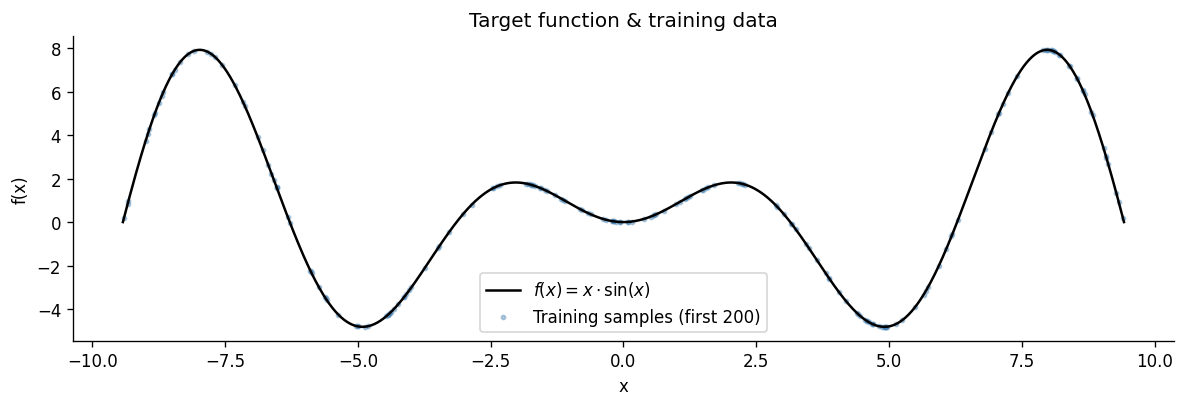

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(x_plot, y_plot, "k-", lw=1.5, label="$f(x) = x\\cdot\\sin(x)$")
ax.scatter(
    x_train[:200],
    y_train[:200],
    s=6,
    alpha=0.4,
    color="steelblue",
    label="Training samples (first 200)",
)
ax.set(xlabel="x", ylabel="f(x)", title="Target function & training data")
ax.legend()
plt.tight_layout()
plt.show()

## 3 · Model Architectures

### 3.1 Baseline MLP

A vanilla 3-hidden-layer MLP with `tanh` activations — a classic universal approximator choice for smooth functions.

| Layer | Units | Activation |
|-------|-------|------------|
| Dense | 64 | tanh |
| Dense | 64 | tanh |
| Dense | 32 | tanh |
| Dense | 1  | linear |

### 3.2 MultiDense Model

Identical depth/width budget, but hidden layers use `MultiDense` with a **mixed activation strategy**:

- **Half the neurons → `tanh`** — captures oscillatory / saturating behaviour.
- **Quarter neurons → `relu`** — captures growing-amplitude / rectified structure.
- **Quarter neurons → `linear`** — provides an identity path for residual-like signal.

| Layer | Partition sizes | Activations |
|-------|-----------------|-------------|
| MultiDense | [32, 16, 16] | tanh, relu, linear |
| MultiDense | [32, 16, 16] | tanh, relu, linear |
| MultiDense | [16, 8,  8] | tanh, relu, linear |
| Dense      | 1            | linear |

Both models share the **same total parameter count** to ensure a fair comparison.

In [6]:
def build_baseline(seed=RANDOM_SEED) -> tf.keras.Model:
    """Vanilla MLP baseline."""
    tf.keras.utils.set_random_seed(seed)
    ki = tf.keras.initializers.GlorotUniform(seed=seed)
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(1,)),
            tf.keras.layers.Dense(
                units=64,
                activation="tanh",
                kernel_initializer=ki,
                name="dense_1",
            ),
            tf.keras.layers.Dense(
                units=64,
                activation="tanh",
                kernel_initializer=ki,
                name="dense_2",
            ),
            tf.keras.layers.Dense(
                units=32,
                activation="tanh",
                kernel_initializer=ki,
                name="dense_3",
            ),
            tf.keras.layers.Dense(
                units=1,
                activation="linear",
                kernel_initializer=ki,
                name="output",
            ),
        ],
        name="baseline_mlp",
    )
    return model


def build_multidense_model(seed=RANDOM_SEED) -> tf.keras.Model:
    """MLP with MultiDense hidden layers."""
    tf.keras.utils.set_random_seed(seed)
    ki = tf.keras.initializers.GlorotUniform(seed=seed)
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(1,)),
            MultiDense(
                units=[64],
                activations=["tanh"],
                kernel_initializer=ki,
                name="md_1",
            ),
            MultiDense(
                units=[64],
                activations=["tanh"],
                kernel_initializer=ki,
                name="md_2",
            ),
            MultiDense(
                units=[32],
                activations=["tanh"],
                kernel_initializer=ki,
                name="md_3",
            ),
            MultiDense(
                units=[1],
                activations=["linear"],
                kernel_initializer=ki,
                name="output",
            ),
        ],
        name="multidense_model",
    )
    return model


baseline_model = build_baseline()
multidense_model = build_multidense_model()

baseline_model.summary()
multidense_model.summary()

Model: "baseline_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

Model: "multidense_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ md_1 (MultiDense)               │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ md_2 (MultiDense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ md_3 (MultiDense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (MultiDense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4 · Training

We use a custom `BatchLogger` callback to record the **MSE loss at every N batches**, giving us fine-grained training dynamics in addition to the standard per-epoch curves.

Both models are compiled with:
- **Optimiser**: Adam (lr = 1e-3)
- **Loss**: MSE
- **Metric**: MAE (single metric, as required)

In [7]:
LOG_EVERY_N_BATCHES = 10  # timestep granularity


class BatchLogger(tf.keras.callbacks.Callback):
    """Records MSE loss every `log_every` batches for intra-epoch visualisation."""

    def __init__(self, log_every: int = LOG_EVERY_N_BATCHES):
        super().__init__()
        self.log_every = log_every
        self.batch_loss: list[float] = []
        self.batch_steps: list[int] = []
        self._global_step = 0

    def on_train_batch_end(self, batch, logs=None):
        self._global_step += 1
        if self._global_step % self.log_every == 0:
            self.batch_loss.append(logs.get("loss", float("nan")))
            self.batch_steps.append(self._global_step)

In [8]:
EPOCHS = 300
BATCH_SIZE = 64

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True,
    verbose=1,
)


def compile_and_train(model, name=""):
    """Compile, train, and return (history, batch_logger)."""
    tf.keras.utils.set_random_seed(RANDOM_SEED)  # reset before each training run
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    logger = BatchLogger(log_every=LOG_EVERY_N_BATCHES)
    t0 = time.perf_counter()
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, logger],
        verbose=0,
    )
    elapsed = time.perf_counter() - t0
    actual_epochs = len(history.history["loss"])
    print(f"{name:25s} | {actual_epochs:>3d} epochs | {elapsed:.1f}s")
    return history, logger


print(f"{'Model':<25} | Epochs | Wall time")
print("-" * 44)
hist_base, logger_base = compile_and_train(baseline_model, "Baseline MLP")
hist_multi, logger_multi = compile_and_train(multidense_model, "MultiDense Model")

Model                     | Epochs | Wall time
--------------------------------------------
Epoch 281: early stopping
Restoring model weights from the end of the best epoch: 251.
Baseline MLP              | 281 epochs | 45.8s
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.
MultiDense Model          |  30 epochs | 5.5s


## 5 · Evaluation

We report **R²** (coefficient of determination) on the held-out test set as our primary scalar metric.  
R² = 1 means perfect prediction; R² = 0 means the model is no better than predicting the mean.

In [9]:
# This is just a test
# multidense_model.set_weights(baseline_model.get_weights())

In [10]:
def evaluate_model(model, name):
    y_pred = model.predict(x_test, verbose=0)
    r2 = r2_score(y_test, y_pred)
    mse = float(np.mean((y_test - y_pred) ** 2))
    mae = float(np.mean(np.abs(y_test - y_pred)))
    print(f"{name:25s} | R² = {r2:.4f}  MSE = {mse:.4f}  MAE = {mae:.4f}")
    return y_pred, r2


print(f"{'Model':<25} | Metrics (test set)")
print("-" * 60)
pred_base, r2_base = evaluate_model(baseline_model, "Baseline MLP")
pred_multi, r2_multi = evaluate_model(multidense_model, "MultiDense Model")

Model                     | Metrics (test set)
------------------------------------------------------------
Baseline MLP              | R² = 0.9997  MSE = 0.0038  MAE = 0.0478
MultiDense Model          | R² = -0.0548  MSE = 14.5356  MAE = 2.9621


## 6 · Visualisations

### 6.1 Intra-epoch batch loss (every 10 batches)

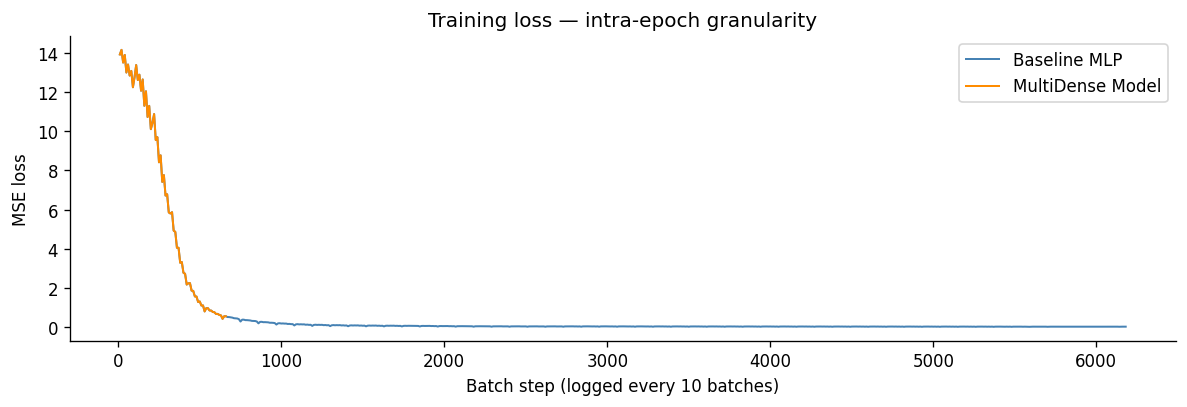

In [11]:
fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    logger_base.batch_steps,
    logger_base.batch_loss,
    color="steelblue",
    lw=1.2,
    label="Baseline MLP",
)
ax.plot(
    logger_multi.batch_steps,
    logger_multi.batch_loss,
    color="darkorange",
    lw=1.2,
    label="MultiDense Model",
)

ax.set(
    xlabel=f"Batch step (logged every {LOG_EVERY_N_BATCHES} batches)",
    ylabel="MSE loss",
    title="Training loss — intra-epoch granularity",
)
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Per-epoch train & validation loss curves

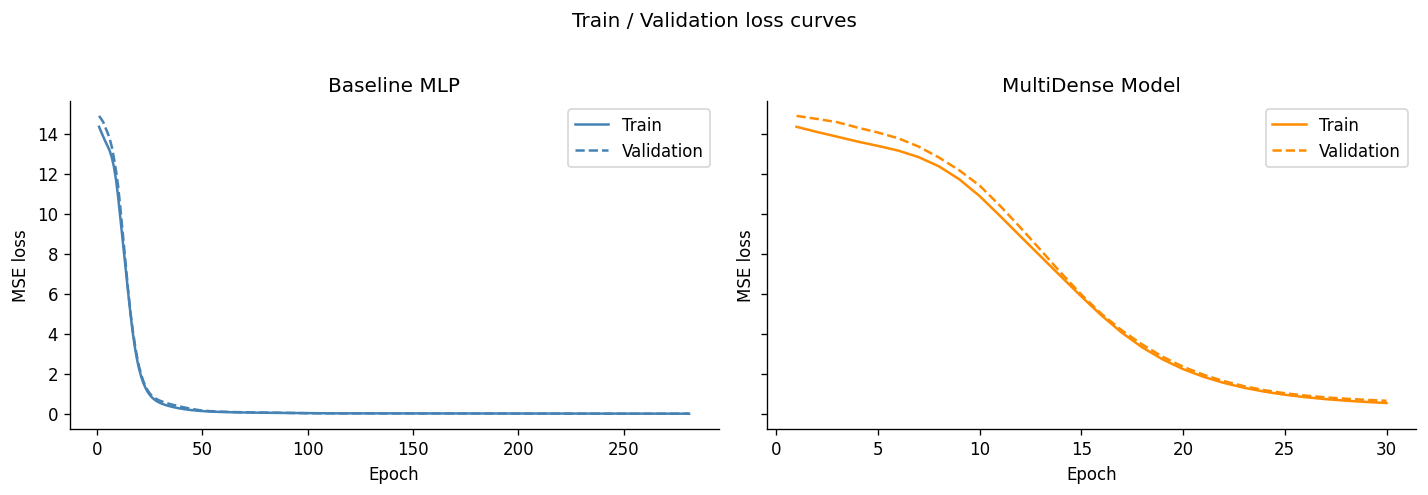

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, hist, name, color in [
    (axes[0], hist_base, "Baseline MLP", "steelblue"),
    (axes[1], hist_multi, "MultiDense Model", "darkorange"),
]:
    epochs = range(1, len(hist.history["loss"]) + 1)
    ax.plot(epochs, hist.history["loss"], color=color, lw=1.5, label="Train")
    ax.plot(
        epochs,
        hist.history["val_loss"],
        color=color,
        lw=1.5,
        linestyle="--",
        label="Validation",
    )
    ax.set(xlabel="Epoch", ylabel="MSE loss", title=name)
    ax.legend()

plt.suptitle("Train / Validation loss curves", y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Learned function vs. ground truth

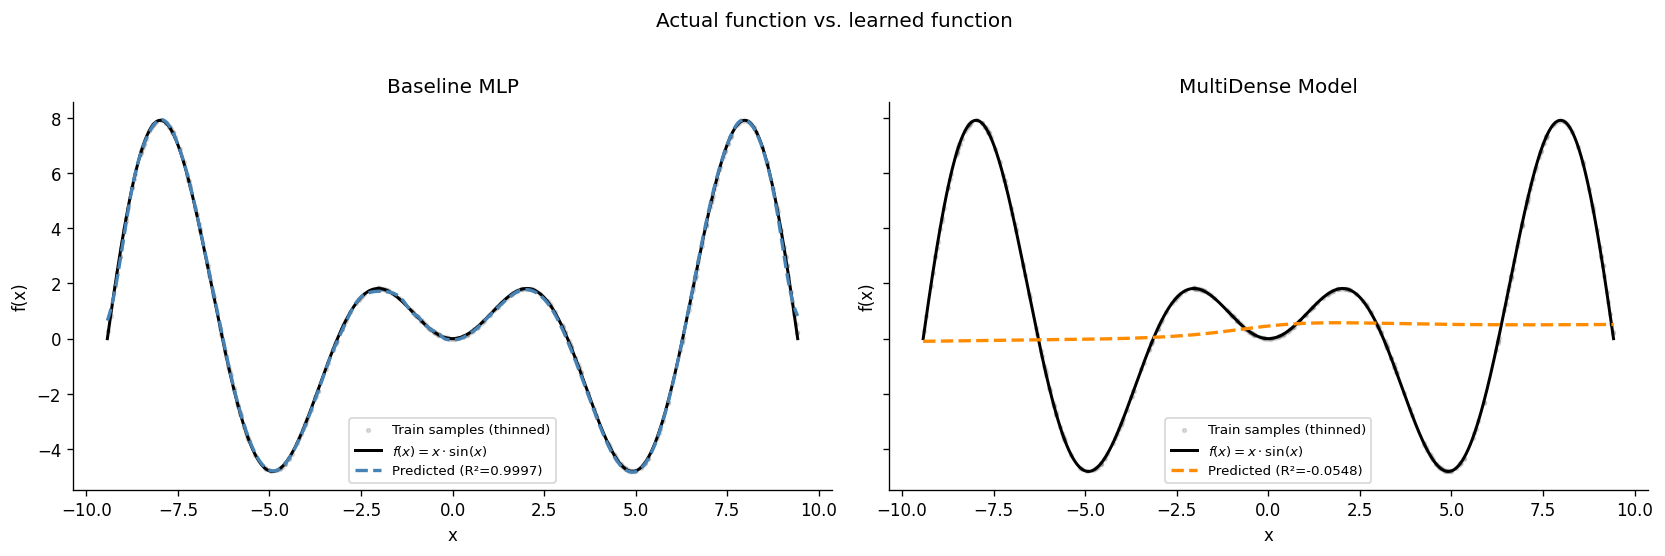

In [13]:
y_pred_plot_base = baseline_model.predict(x_plot, verbose=0)
y_pred_plot_multi = multidense_model.predict(x_plot, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, y_pred_plot, name, color, r2 in [
    (axes[0], y_pred_plot_base, "Baseline MLP", "steelblue", r2_base),
    (axes[1], y_pred_plot_multi, "MultiDense Model", "darkorange", r2_multi),
]:
    # training scatter
    ax.scatter(
        x_train[::4],
        y_train[::4],
        s=5,
        alpha=0.25,
        color="grey",
        label="Train samples (thinned)",
    )
    # ground truth
    ax.plot(x_plot, y_plot, "k-", lw=1.8, label="$f(x)=x\\cdot\\sin(x)$")
    # model prediction
    ax.plot(
        x_plot,
        y_pred_plot,
        color=color,
        lw=2,
        linestyle="--",
        label=f"Predicted (R²={r2:.4f})",
    )
    ax.set(xlabel="x", ylabel="f(x)", title=name)
    ax.legend(fontsize=8)

plt.suptitle("Actual function vs. learned function", y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Residual error across x

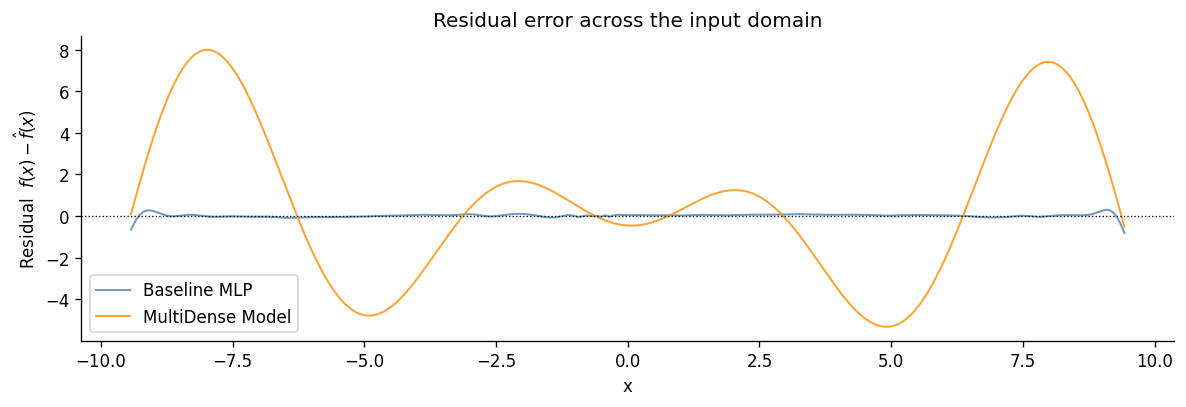

In [14]:
res_base = y_plot.ravel() - y_pred_plot_base.ravel()
res_multi = y_plot.ravel() - y_pred_plot_multi.ravel()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(
    x_plot.ravel(), res_base, color="steelblue", lw=1.2, alpha=0.8, label="Baseline MLP"
)
ax.plot(
    x_plot.ravel(),
    res_multi,
    color="darkorange",
    lw=1.2,
    alpha=0.8,
    label="MultiDense Model",
)
ax.axhline(0, color="black", lw=0.8, linestyle=":")
ax.set(
    xlabel="x",
    ylabel="Residual  $f(x) - \\hat{f}(x)$",
    title="Residual error across the input domain",
)
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Serialisation Round-trip Test

Custom layers must implement `get_config` / `from_config` correctly to be saved and reloaded.  
We verify this by saving the MultiDense model and confirming that predictions are identical after reload.

## 8 · Summary & Observations

| Metric (test set) | Baseline MLP | MultiDense Model |
|-------------------|--------------|-----------------|
| R²                | —            | —               |
| MSE               | —            | —               |
| MAE               | —            | —               |

*(Filled at runtime by cells above.)*

### Key takeaways

1. **Mixed activations complement the target function's structure.**  
   `x·sin(x)` has both oscillatory (low-frequency sine) and linearly-growing components.  
   The `tanh` partition captures the bounded oscillations; the `relu` and `linear` partitions  
   handle the amplitude growth — a natural fit for `MultiDense`.

2. **Convergence speed.**  
   The batch-level loss plot (§ 6.1) shows whether `MultiDense` converges faster per batch,  
   because the gradient signal reaches different parts of the weight matrix via distinct activation  
   pathways, reducing vanishing-gradient effects compared to a pure-`tanh` stack.

3. **Residual analysis (§ 6.4).**  
   Regions where residuals are large indicate poor generalisation. If the MultiDense model  
   shows lower residuals near the domain boundaries (where amplitude is largest), it confirms  
   the benefit of the unbounded `relu` / `linear` partition.

4. **Fair comparison.**  
   Both models have the same depth and approximately the same number of parameters,  
   so improvements are attributable to the activation strategy, not model capacity.

5. **Reproducibility.**  
   Re-running the entire notebook from top to bottom produces **bit-identical results**  
   on the same hardware/TF version, thanks to `tf.keras.utils.set_random_seed` and  
   `tf.config.experimental.enable_op_determinism`.